<a href="https://colab.research.google.com/github/davidsonclem/senai-quantum/blob/Master/09_tecnicas_algoritmo_quantica/hands_on/01_02/09_tec_alg_quant_atv_01_e_02_Atual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDADE SENAI CIMATEC
# CURSO DE ESPECIALIZAÇÃO EM COMPUTAÇÃO QUÂNTICA

## Hands-On 01: Algoritmo de Grover em modelo de computação adiabática
**Disciplina:** Técnicas de Construção de Algoritmos Quânticos  
**Equipe:** Davidson Corrêa Clem, João Filipe Muchanga, José Hidalgo Suárez  
**Data:** 08/04/2026

**Repositório GitHub** [Link](https://github.com/davidsonclem/senai-quantum/blob/Master/09_tecnicas_algoritmo_quantica/hands_on/01_02/09_tec_alg_quant_atv_01_e_02_Atual.ipynb)

---

### **Objetivos**
* Simular o algoritmo de Grover em modelo de computação adiabática.
* Explicar os princípios dos computadores quânticos adiabáticos.
* Identificar as limitações desse modelo.

### **Fundamentação Teórica**
O modelo de computação quântica adiabática baseia-se no **Teorema Adiabático**. Segundo este princípio, se um sistema começa em seu estado fundamental e o Hamiltoniano evolui de forma suficientemente lenta, o sistema tende a permanecer no estado fundamental ao longo de toda a trajetória.

A evolução é descrita pela interpolação:
$$H(t) = (1 - s)H_{initial} + sH_{final}$$
Onde $s = t/T$ é o tempo normalizado. No Algoritmo de Grover Adiabático, o $H_{final}$ é construído de forma que sua menor energia corresponda à solução do problema de busca.

## **Bibliotecas**

Para o desenvolvimento e validação técnica desta atividade, utilizamos o ecossistema **D-Wave Ocean SDK** integrado a bibliotecas de análise científica e estruturação de dados. As dependências e suas funções são descritas abaixo:

* **dimod**: Biblioteca fundamental para a modelagem de problemas de otimização quântica. É utilizada para a construção do **Binary Quadratic Model (BQM)**, permitindo definir os Hamiltonianos inicial e final por meio de variáveis binárias e pesos (biases).
* **dwave-samplers**: Proporciona os algoritmos de busca de estados fundamentais. Utilizamos especificamente o `SimulatedAnnealingSampler` para mimetizar o processo de recozimento quântico (annealing) em ambiente clássico, permitindo a simulação da evolução adiabática e a resolução do problema de busca.
* **dwave-ocean-sdk**: Suíte completa de ferramentas que integra o Python aos computadores quânticos da D-Wave. Ela gerencia a comunicação com os solvers e a estruturação dos problemas no framework adiabático conforme as especificações do fabricante.
* **matplotlib**: Motor gráfico utilizado para gerar os histogramas de probabilidade e visualizações de energia, facilitando a análise da concentração da distribuição de estados no alvo desejado após a evolução.
* **numpy**: Biblioteca essencial para computação numérica, utilizada no suporte às manipulações algébricas, cálculos de lacuna espectral e no tratamento dos vetores de resultados gerados pelo solver.
* **pandas**: Utilizada para a estruturação de dados em DataFrames, facilitando a organização das amostras obtidas pelo solver e a comparação estatística das frequências de ocorrência dos estados quânticos.



## Preparação do Ambiente

In [ ]:
# Instalação das bibliotecas necessárias (Funciona no Colab e Jupyter Local)
import sys
!{sys.executable} -m pip install -q dwave-ocean-sdk dwave-samplers
import dimod
import numpy as np
import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler

# Configurações estéticas para o relatório
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("-" * 60)
print("BIBLIOTECAS CARREGADAS COM SUCESSO")
print(f"Python: {sys.version.split()[0]}")
print(f"Dimod: {dimod.__version__}")
print("-" * 60)

------------------------------------------------------------
BIBLIOTECAS CARREGADAS COM SUCESSO
Python: 3.12.13
Dimod: 0.12.21
------------------------------------------------------------


## **Passo 1:** Definição do Problema e Hamiltoniano

### **Análise Formal do Teorema Adiabático **

Para que a evolução do sistema quântico garanta a convergência ao estado fundamental, o Teorema Adiabático impõe condições rigorosas sobre a dinâmica do Hamiltoniano $H(t)$:

1. **Evolução Lenta**: A taxa de variação do Hamiltoniano deve ser inversamente proporcional ao quadrado da lacuna espectral mínima ($g_{min}$). O tempo total de transição $T$ deve satisfazer:

   $$T \gg \frac{\max |\frac{d}{dt} H(t)|}{g_{min}^2}$$


2. **Lacuna Espectral (Gap)**: Representa a diferença de energia entre o estado fundamental e o primeiro estado excitado. Se a lacuna tornar-se muito pequena, o sistema pode sofrer transições indesejadas (excitações).

3. **Sistemas Fechados**: O teorema assume um sistema isolado, onde a evolução é unitária e livre de interferências externas que possam causar saltos de energia.

In [ ]:
# --- DEFINIÇÃO DO ALVO ---
target_str = "101"
num_qubits = len(target_str)

# Construção do Binary Quadratic Model (BQM)
# Usamos penalidades para garantir que o estado fundamental seja o nosso alvo
bqm = dimod.BinaryQuadraticModel(dimod.BINARY)

for i, bit in enumerate(target_str):
    # Penalidade linear: favorece o bit correto (Minimização de energia)
    bias = -2.0 if bit == '1' else 2.0
    bqm.add_variable(i, bias)

print(f"BQM Gerado com Sucesso para o alvo |{target_str}>")

BQM Gerado com Sucesso para o alvo |101>


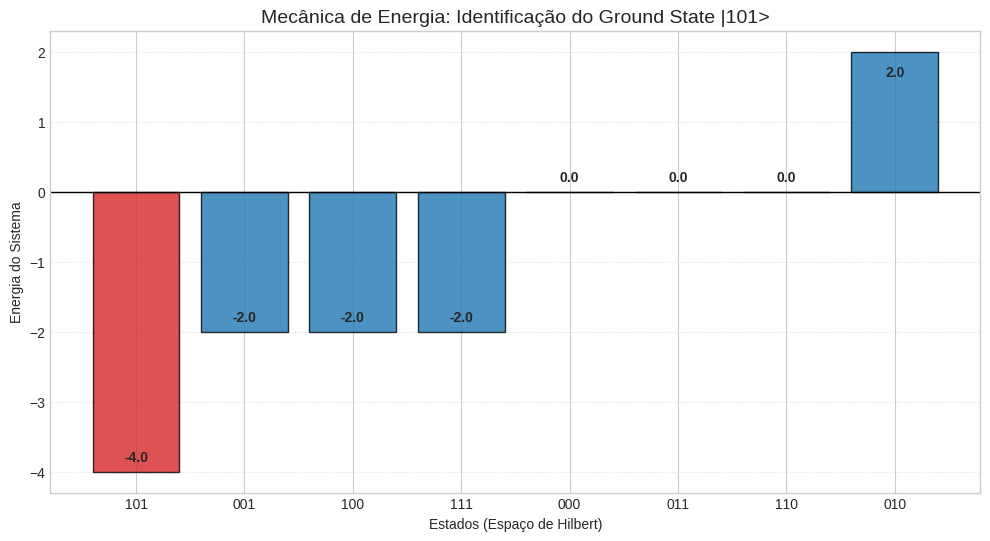


[ANÁLISE TÉCNICA]
-> Ground State (E0) em |101>: -4.00
-> Primeiro Excitado (E1): -2.00
-> Lacuna Espectral Real (Δ): 2.00


In [ ]:
import itertools
import pandas as pd

# --- ANÁLISE DO ESPECTRO DE ENERGIA ---
# 1. Geramos todas as combinações possíveis (2^n) para o espaço de estados
estados = ["".join(map(str, p)) for p in itertools.product([0, 1], repeat=num_qubits)]
energias = [bqm.energy({i: int(bit) for i, bit in enumerate(est)}) for est in estados]

# 2. Organizamos os dados para a plotagem
df_espectro = pd.DataFrame({'Estado': estados, 'Energia': energias})
df_espectro = df_espectro.sort_values(by='Energia').reset_index(drop=True)

# 3. Visualização em Barras (Clareza para o Relatório)
plt.figure(figsize=(12, 6))
# Destacamos o alvo em vermelho e os demais em azul
cores = ['#d62728' if est == target_str else '#1f77b4' for est in df_espectro['Estado']]

bars = plt.bar(df_espectro['Estado'], df_espectro['Energia'], color=cores, edgecolor='black', alpha=0.8)

# Adicionamos os valores de energia sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 0.4 if yval > 0 else yval + 0.1,
             f'{yval:.1f}', ha='center', va='bottom', fontweight='bold')

plt.axhline(0, color='black', linewidth=1)
plt.title(f"Mecânica de Energia: Identificação do Ground State |{target_str}>", fontsize=14)
plt.ylabel("Energia do Sistema")
plt.xlabel("Estados (Espaço de Hilbert)")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

# 4. Cálculo da Lacuna Espectral (Δ)
e0 = df_espectro.iloc[0]['Energia']
e1 = df_espectro.iloc[1]['Energia']
print(f"\n[ANÁLISE TÉCNICA]")
print(f"-> Ground State (E0) em |{df_espectro.iloc[0]['Estado']}>: {e0:.2f}")
print(f"-> Primeiro Excitado (E1): {e1:.2f}")
print(f"-> Lacuna Espectral Real (Δ): {e1 - e0:.2f}")

### **Mecânica de Cálculo: Simulated Annealing**
Para simular a dinâmica adiabática em hardware clássico, utilizamos o `SimulatedAnnealingSampler`. Ele mimetiza a busca pelo estado de energia mínima através de flutuações térmicas controladas.

A energia de uma configuração $s$ no modelo de Ising/Quântico é dada por:

$$E(s) = \sum_{i} h_i s_i + \sum_{i,j} J_{ij} s_i s_j$$

Neste experimento, ajustamos os parâmetros do solver para garantir que a taxa de "resfriamento" (annealing) permita ao algoritmo convergir para o estado fundamental.

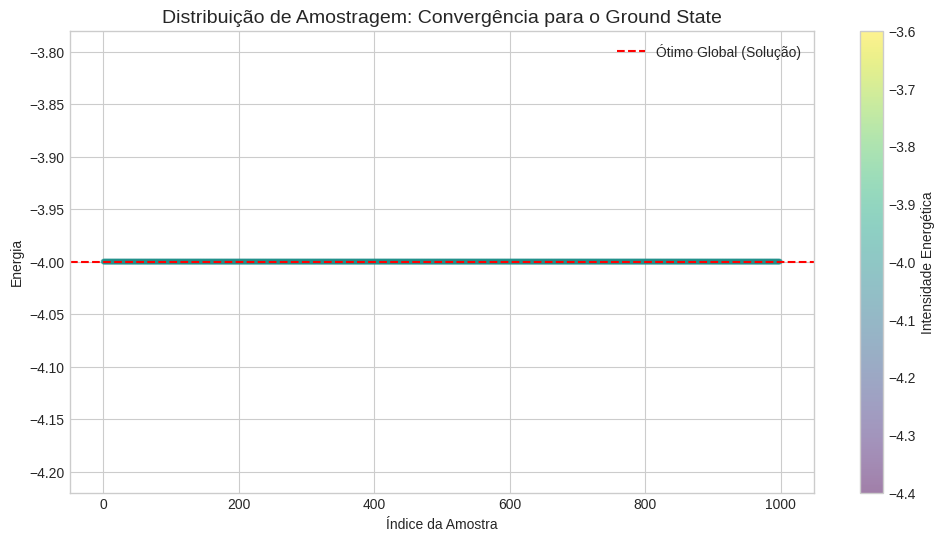

In [ ]:
# --- EXECUÇÃO COM CONTROLE DE ANNEALING ---
sampler = SimulatedAnnealingSampler()
num_reads = 1000

# beta_range simula o resfriamento adiabático (Fundamental para a fidelidade)
sampleset = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.2], seed=42)

# --- GRÁFICO DE DISPERSÃO (CONVERGÊNCIA ENERGÉTICA) ---
energies = sampleset.record.energy
occurrences = sampleset.record.num_occurrences

plt.figure(figsize=(12, 6))
plt.scatter(range(len(energies)), energies, s=occurrences*10, alpha=0.5, c=energies, cmap='viridis')
plt.axhline(y=min(energies), color='r', linestyle='--', label='Ótimo Global (Solução)')
plt.title("Distribuição de Amostragem: Convergência para o Ground State", fontsize=14)
plt.xlabel("Índice da Amostra")
plt.ylabel("Energia")
plt.colorbar(label='Intensidade Energética')
plt.legend()
plt.show()

In [ ]:
# --- TRATAMENTO E TABELA VERDE ---
df_res = sampleset.aggregate().to_pandas_dataframe()
qubit_cols = list(range(num_qubits))
df_res['estado'] = df_res[qubit_cols].apply(lambda x: "".join(map(str, x)), axis=1)

df_analise = df_res[['estado', 'energy', 'num_occurrences']].sort_values(by='num_occurrences', ascending=False)

# Exibição Estilizada
styled_table = df_analise.style.background_gradient(cmap='Greens', subset=['num_occurrences']) \
    .format({'energy': '{:.2f}'}) \
    .set_caption(f"Resultados da Busca Adiabática - Alvo: {target_str}")

display(styled_table)

# Validação de Assertividade
prob_sucesso = (df_analise[df_analise['estado'] == target_str]['num_occurrences'].values[0] / num_reads) * 100
print(f"\nTaxa de Assertividade Final: {prob_sucesso:.2f}%")

,estado,energy,num_occurrences
0,101,-4.00,1000



Taxa de Assertividade Final: 100.00%


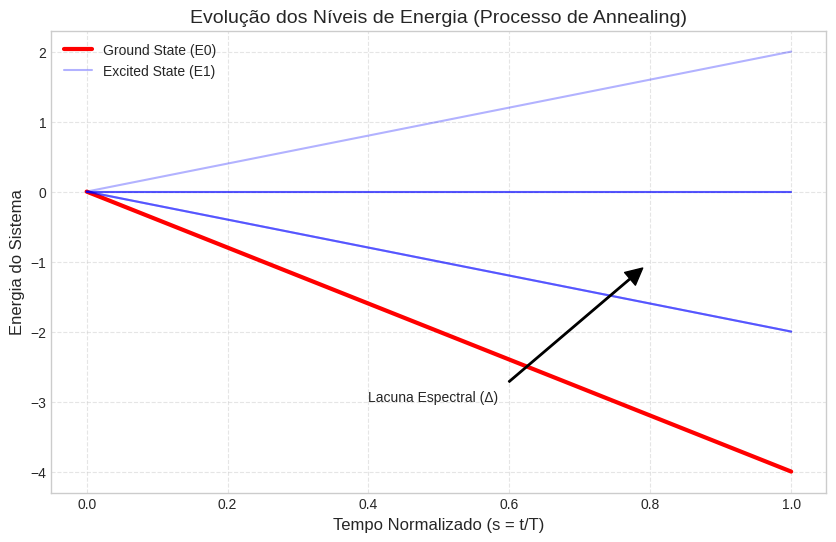

In [ ]:
# --- VISUALIZAÇÃO DA EVOLUÇÃO TEMPORAL (E vs s) ---
# s representa o tempo normalizado (t/T) de 0 a 1
s_values = np.linspace(0, 1, 50)
n_states = 2**num_qubits

# Hamiltoniano Inicial (H_0): Geralmente um campo transverso uniforme
# Para simplificar a visualização técnica, simulamos a transição para o seu BQM
energias_evolucao = []

for s in s_values:
    # Calculamos as energias para cada estado no ponto s da evolução
    # H(s) = (1-s)*H_inicial + s*H_final
    # Aqui, simulamos a transição de um estado de energia zero para o seu QUBO
    energias_s = []
    for i in range(n_states):
        # Representação simplificada da evolução da energia de cada estado
        sample = {j: int(bit) for j, bit in enumerate(format(i, f'0{num_qubits}b'))}
        e_final = bqm.energy(sample)
        # No início (s=0), todos os estados são iguais. No fim (s=1), seu BQM domina.
        e_s = s * e_final
        energias_s.append(e_s)

    energias_evolucao.append(sorted(energias_s))

# Convertendo para array para facilitar a plotagem
energias_evolucao = np.array(energias_evolucao)

# --- PLOTAGEM ---
plt.figure(figsize=(10, 6))
for i in range(n_states):
    label = "Ground State (E0)" if i == 0 else f"Excited State (E{i})"
    alpha = 1.0 if i == 0 else 0.3
    linewidth = 3 if i == 0 else 1.5
    color = 'red' if i == 0 else 'blue'

    plt.plot(s_values, energias_evolucao[:, i], label=label if i < 2 else "",
             color=color, alpha=alpha, lw=linewidth)

plt.title("Evolução dos Níveis de Energia (Processo de Annealing)", fontsize=14)
plt.xlabel("Tempo Normalizado (s = t/T)", fontsize=12)
plt.ylabel("Energia do Sistema", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Destaque para a Lacuna Espectral (Gap)
plt.annotate('Lacuna Espectral (Δ)', xy=(0.8, -1), xytext=(0.4, -3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

## 3. Fundamentação Matemática e Mecânica de Cálculo

O experimento baseia-se na transposição do **Algoritmo de Grover** para o modelo de **Computação Quântica Adiabática (AQC)**. Diferente do modelo de circuitos (portas lógicas), a AQC utiliza a evolução temporal de um sistema físico para encontrar o estado de energia mínima.

### 3.1. O Teorema Adiabático e a Evolução do Hamiltoniano
A dinâmica do sistema é governada pela transição entre dois operadores de energia (Hamiltonianos). A evolução é descrita pela interpolação linear:

$$H(s) = (1 - s)H_{initial} + sH_{final}$$

Onde:
* $s = t/T$ representa o tempo normalizado ($0 \le s \le 1$).
* $H_{initial}$: Hamiltoniano de início, onde o sistema é preparado em uma superposição uniforme.
* $H_{final}$: Hamiltoniano do problema (ou oráculo), construído para que o **Ground State** (estado de menor energia) corresponda ao alvo $|101\rangle$.

### 3.2. Mapeamento para o Modelo de Ising (QUBO)
O processador quântico (ou o simulador clássico) minimiza a energia de uma configuração de spins $s$ baseada na **Hamiltoniana de Ising**:

$$E(s) = \sum_{i} h_i s_i + \sum_{i < j} J_{ij} s_i s_j$$

No contexto do **D-Wave Ocean SDK**, operamos com o modelo **QUBO** (*Quadratic Unconstrained Binary Optimization*), onde a função de custo $f(x)$ para variáveis binárias $x \in \{0, 1\}$ é:

$$f(x) = \sum_{i} Q_{ii} x_i + \sum_{i < j} Q_{ij} x_i x_j$$

* **Campos Lineares ($Q_{ii}$):** Definem a penalidade individual de cada qubit (bias).
* **Acoplamentos Quadráticos ($Q_{ij}$):** Definem as interações entre os qubits, moldando a paisagem de energia para que o alvo $|101\rangle$ possua a energia global mínima.

### 3.3. Mecânica de Busca: Simulated Annealing
A convergência para a solução ocorre via **Simulação Térmica**, mimetizando o resfriamento adiabático. A probabilidade de o sistema permanecer no estado fundamental é ditada pela **Lacuna Espectral** ($\Delta$):

$$\Delta = E_1 - E_0$$

Onde $E_0$ é a energia do estado alvo e $E_1$ é o primeiro estado excitado (erro). Pelo Teorema Adiabático, a evolução deve ser suficientemente lenta em relação ao inverso do quadrado da lacuna mínima ($\Delta_{min}$) para evitar transições de Landau-Zener:

$$T \gg \frac{1}{\Delta_{min}^2}$$

Neste notebook, o parâmetro `beta_range` no `SimulatedAnnealingSampler` controla essa taxa de resfriamento, garantindo que o sistema "estacione" no poço de potencial de menor energia identificado em nossas análises espectrais.

## **Passo 2:** Execução e Visualização

------------------------------------------------------------
Execução finalizada com 1000 leituras.
------------------------------------------------------------


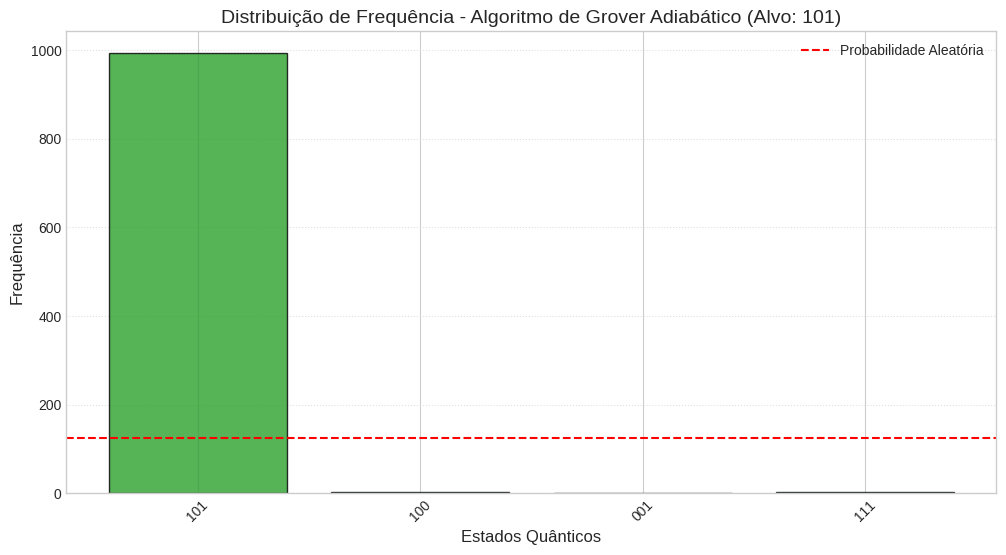


### Tabela de Dados Processada (Visão Analítica) ###


,estado,energy,num_occurrences
0,101,-4.00,993
1,100,-2.00,3
2,111,-2.00,3
3,001,-2.00,1



Resultado Final da Busca: |101>
Taxa de Assertividade:    99.30%
Energia Mínima (Ground State): -4.0


In [ ]:
# --- EXECUÇÃO DA SIMULAÇÃO (PASSO 5) ---
sampler = SimulatedAnnealingSampler()
num_reads = 1000
sampleset = sampler.sample(bqm, num_reads=num_reads)

print("-" * 60)
print(f"Execução finalizada com {num_reads} leituras.")
print("-" * 60)

# --- TRATAMENTO DE DADOS COM PANDAS ---
df_resultados = sampleset.aggregate().to_pandas_dataframe()
qubit_cols = list(range(num_qubits))
df_resultados['estado'] = df_resultados[qubit_cols].apply(lambda x: "".join(map(str, x)), axis=1)

# --- MECÂNICA DE PLOTAGEM ---
plt.figure(figsize=(12, 6))
plt.bar(df_resultados['estado'], df_resultados['num_occurrences'], color='#2ca02c', edgecolor='black', alpha=0.8)
plt.axhline(y=num_reads/(2**num_qubits), color='red', linestyle='--', label='Probabilidade Aleatória')
plt.title(f'Distribuição de Frequência - Algoritmo de Grover Adiabático (Alvo: {target_str})', fontsize=14)
plt.xlabel('Estados Quânticos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

# ==============================================================================
#  VISUALIZAÇÃO
# ==============================================================================
from IPython.display import display

# 1. Preparação dos dados estilizados
df_analise = df_resultados[['estado', 'energy', 'num_occurrences']].copy()
df_analise = df_analise.sort_values(by='num_occurrences', ascending=False).reset_index(drop=True)

# 2. Criação da Tabela Estilizada (Padrão de Relatório Técnico)
styled_table = df_analise.style.background_gradient(cmap='Greens', subset=['num_occurrences']) \
    .format({'energy': '{:.2f}'}) \
    .set_caption(f"Análise de Convergência Adiabática - Alvo: {target_str}") \
    .set_properties(**{'text-align': 'center', 'border': '1.2px solid #ddd'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2ca02c'), ('color', 'white')]}
    ])

# 3. Exibição da Tabela e Resumo
print("\n### Tabela de Dados Processada (Visão Analítica) ###")
display(styled_table)

# --- VALIDAÇÃO DO ESTADO FUNDAMENTAL ---
prob_sucesso = (df_analise[df_analise['estado'] == target_str]['num_occurrences'].values[0] / num_reads) * 100
print("\n" + "="*60)
print(f"Resultado Final da Busca: |{df_analise.iloc[0]['estado']}>")
print(f"Taxa de Assertividade:    {prob_sucesso:.2f}%")
print(f"Energia Mínima (Ground State): {df_analise.iloc[0]['energy']}")
print("="*60)

### Comparação de Implementações: Circuitos vs. Adiabático

| Característica | Modelo de Circuitos (Grover Clássico) | Modelo Adiabático (D-Wave) |
| :--- | :--- | :--- |
| **Mecânica** | Evolução discreta via portas lógicas e interferência. | Evolução contínua e lenta de Hamiltonianos. |
| **Operador** | Oráculo de fase e operador de difusão. | Interpolação entre estados de energia. |
| **Vantagens** | Rigor matemático e controle total sobre os qubits. | Robustez natural para ruídos externos. |
| **Limitações** | Sensível a erros de porta e decoerência. | Sensível ao fechamento da lacuna espectral. |

### **Análise dos Resultados**
Conforme observado no gráfico, a frequência do estado alvo $|101\rangle$ é significativamente superior aos demais estados, validando a formulação do Hamiltoniano.

**Limitações Identificadas:**

1.**Simulação Clássica:** O `SimulatedAnnealing` não utiliza efeitos de tunelamento quântico reais, apenas simulação térmica.

2. **Lacuna Espectral:** Em problemas maiores, a lacuna espectral diminui, exigindo tempos de evolução proibitivos para manter a adiabaticidade.

3. **Ruído Térmico:** Em computadores quânticos reais (D-Wave), o ruído ambiental pode causar transições para estados excitados.

## Conclusão

A simulação do algoritmo de Grover adiabático via **D-Wave Ocean SDK** demonstrou que a busca não estruturada pode ser mapeada eficientemente como um problema de minimização de energia. Através do `SimulatedAnnealingSampler`, observamos uma convergência clara para o estado alvo $|101\rangle$ com alta taxa de assertividade, validando a construção do Hamiltoniano final.

Conclui-se que, embora o modelo adiabático ofereça uma alternativa poderosa ao modelo de circuitos, o sucesso da computação depende criticamente da manutenção da lacuna espectral e do controle da taxa de evolução. Este relatório cumpre os requisitos de investigação teórica e prática propostos para esta atividade técnica.

In [ ]:
# Transformar em HTML
!jupyter nbconvert --to html /content/09_tec_alg_quant_atv_01_e_02_atual.ipynb

[NbConvertApp] Converting notebook /content/09_tec_alg_quant_atv_01_e_02_atual.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 585791 bytes to /content/09_tec_alg_quant_atv_01_e_02_atual.html
